# Grover's algorithm: searching an unsorted list with fewer queries

## The problem

There are $N = 2^n$ possible items, and a black box (the "oracle") that can tell us whether a given item is one of the $M$ "marked" ones. Find a marked item. With no structure to exploit, a classical search checks about $N/2$ items on average. Grover's algorithm needs only about

$$\frac{\pi}{4}\sqrt{\frac{N}{M}}$$

oracle calls, a quadratic speedup.

## How it works

Start in an equal superposition of all $N$ items (Hadamards). Then repeat a two-step **Grover iteration**:

1. **Oracle**: flip the sign (phase) of each marked state. The probabilities don't change yet, but the marked states now point the opposite way from the rest.
2. **Diffuser**: reflect every amplitude about the average amplitude. Because the marked states are below average after step 1, this boosts them.

Geometrically, each iteration rotates the state by an angle $2\theta$ toward the marked states, where $\sin\theta = \sqrt{M/N}$. After $k$ iterations,

$$P(\text{success}) = \sin^2\big((2k+1)\theta\big).$$

This peaks near $k = \frac{\pi}{4\theta} - \frac12$. Running *more* iterations rotates past the target and the success probability falls again.

**Circuit:** $H^{\otimes n}$, then $k$ times [oracle, diffuser], then measure.

## How the reflections are built

Both steps need a gate that flips the sign of one specific basis state. We build it from a multi-controlled Z: X gates turn the target pattern into all ones, the multi-controlled Z flips the sign of the all-ones state, and the X gates are then undone. The diffuser is this same gate for the state $|00\ldots0\rangle$, sandwiched between Hadamard layers.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

The search settings are here too: `n` qubits (so $2^n$ items), the `marked` item(s) as integers, and `iterations`, a list of iteration counts to try (`None` means the optimal count).

In [1]:
import math
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# _common.py (in the folder above) runs circuits on Aer and/or IBM hardware.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

SETTINGS = SimpleNamespace(
    shots=4096,
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)

n = 3                # number of qubits; the search space has 2**n items
marked = [0b101]     # marked item(s), as integers
iterations = None    # e.g. [0, 1, 2, 3]; None means the optimal count

## Step 1: Flip the phase of one basis state

The helper `_flip_phase_of` multiplies the amplitude of one basis state by $-1$ and leaves all others alone. Qubit $i$ is bit $i$ of `state`. We put X gates on every qubit where the target has a 0, so the target becomes $11\ldots1$. A multi-controlled Z (written as H, multi-controlled X, H on the last qubit) flips the sign of $|11\ldots1\rangle$. Then the X gates are undone.

In [2]:
def _flip_phase_of(circuit: QuantumCircuit, qubits: list, state: int) -> None:
    # X on every qubit where state has a 0, so the target becomes 11...1.
    zeros = [q for i, q in enumerate(qubits) if not (state >> i) & 1]
    if zeros:
        circuit.x(zeros)
    # Multi-controlled Z, written as H - multi-controlled X - H on the last qubit.
    circuit.h(qubits[-1])
    circuit.mcx(qubits[:-1], qubits[-1])
    circuit.h(qubits[-1])
    if zeros:
        circuit.x(zeros)

## Step 2: The oracle

The oracle flips the sign of every marked state. Here it is for our settings.

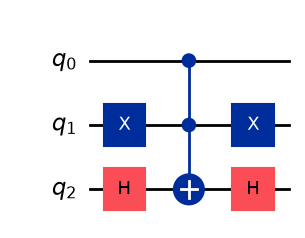

In [3]:
def build_oracle(n: int, marked: list[int]) -> QuantumCircuit:
    oracle = QuantumCircuit(n, name="oracle")
    for w in marked:
        _flip_phase_of(oracle, list(oracle.qubits), w)
    return oracle


build_oracle(n, marked).draw("mpl")

## Step 3: The diffuser

The diffuser reflects amplitudes about their average ("inversion about the mean"). It is built by flipping the sign of $|00\ldots0\rangle$ between two layers of Hadamards. This matches inversion about the mean up to a global phase, which has no effect.

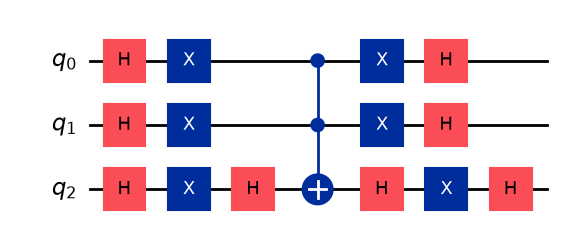

In [4]:
def build_diffuser(n: int) -> QuantumCircuit:
    diffuser = QuantumCircuit(n, name="diffuser")
    diffuser.h(range(n))
    _flip_phase_of(diffuser, list(diffuser.qubits), 0)
    diffuser.h(range(n))
    return diffuser


build_diffuser(n).draw("mpl")

## Step 4: How many iterations?

With $\sin\theta = \sqrt{M/N}$, the best iteration count is the integer nearest $\frac{\pi}{4\theta} - \frac12$ (we use at least 1).

In [5]:
def optimal_iterations(n: int, num_marked: int) -> int:
    theta = math.asin(math.sqrt(num_marked / 2**n))
    return max(1, round(math.pi / (4 * theta) - 0.5))


print("Optimal iteration count:", optimal_iterations(n, len(marked)))

Optimal iteration count: 2


## Step 5: The full Grover circuit

Hadamards on every qubit make the equal superposition. Then we apply (oracle, diffuser) `iterations` times, with barriers to separate the iterations visually, and measure all qubits.

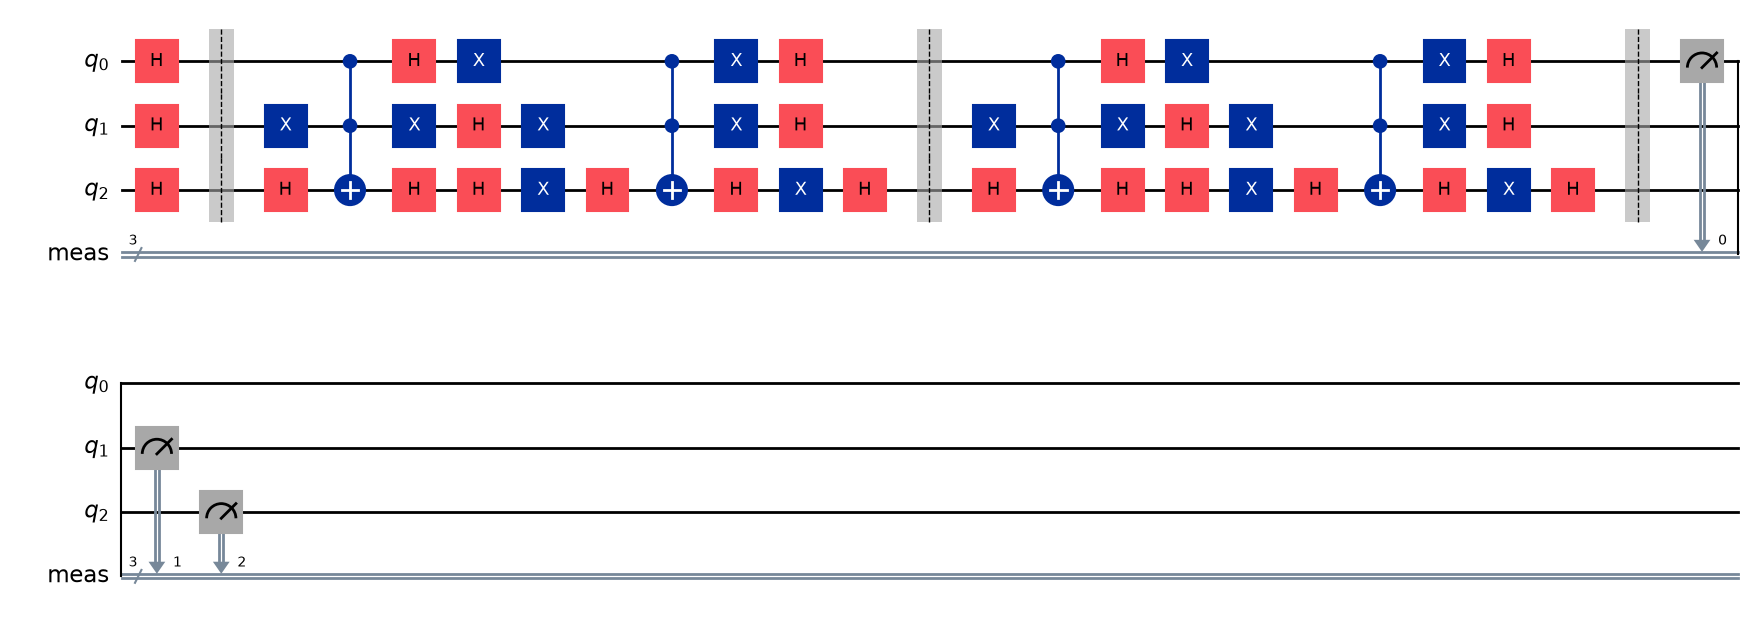

In [6]:
def build_grover_circuit(n: int, marked: list[int], iterations: int) -> QuantumCircuit:
    qubits = QuantumRegister(n, name="q")
    bits = ClassicalRegister(n, name="meas")
    circuit = QuantumCircuit(qubits, bits, name=f"grover_k={iterations}")
    circuit.h(qubits)  # equal superposition of all items
    oracle, diffuser = build_oracle(n, marked), build_diffuser(n)
    for _ in range(iterations):
        circuit.barrier()
        circuit.compose(oracle, inplace=True)
        circuit.compose(diffuser, inplace=True)
    circuit.barrier()
    circuit.measure(qubits, bits)
    return circuit


build_grover_circuit(n, marked, optimal_iterations(n, len(marked))).draw("mpl")

## Step 6: Choose circuits and write the report

We build one circuit per iteration count. The `report` function compares the measured probability of seeing a marked item with the ideal value $\sin^2((2k+1)\theta)$ and with a random guess, $M/N$. Qiskit prints bitstrings with qubit 0 on the *right*, so the marked integer 5 appears as `"101"`.

In [7]:
marked = sorted(set(marked))
marked_strings = {f"{w:0{n}b}" for w in marked}
ks = iterations or [optimal_iterations(n, len(marked))]
print(f"Grover, n={n} (N={2**n}), marked = {sorted(marked_strings)}, iterations = {ks}")

circuits = {f"k={k}": build_grover_circuit(n, marked, k) for k in ks}


def report(prefix: str, name: str, counts: dict) -> None:
    total = sum(counts.values())
    p = sum(c for s, c in counts.items() if s in marked_strings) / total
    k = int(name.split("=")[1])
    theta = math.asin(math.sqrt(len(marked) / 2**n))
    ideal = math.sin((2 * k + 1) * theta) ** 2
    print(
        f"[{prefix}] {name:<5} P(marked) = {p:.3f} (ideal {ideal:.3f}; "
        f"random guess {len(marked) / 2**n:.3f})"
    )
    top = sorted(counts.items(), key=lambda kv: -kv[1])[:4]
    print(f"[{prefix}] top counts: {dict(top)}")

Grover, n=3 (N=8), marked = ['101'], iterations = [2]


## Step 7: Run

`run_experiments` runs each circuit on Aer and, if `skip_hardware` is False, on IBM hardware. With $n=3$ and one marked item, $\theta \approx 0.361$, so two iterations give $\sin^2(5\theta) \approx 0.945$. The marked item `101` should dominate the counts.

In [8]:
args = SimpleNamespace(
    shots=SETTINGS.shots,
    backend=SETTINGS.backend,
    name=SETTINGS.name,
    skip_hardware=SETTINGS.skip_hardware,
    poll_interval=SETTINGS.poll_interval,
)
run_experiments(circuits, args, report);

Example circuit (grover_k=2):
        ┌───┐ ░           ┌───┐┌───┐               ┌───┐┌───┐      ░           »
   q_0: ┤ H ├─░────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────░────────■──»
        ├───┤ ░ ┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤      ░ ┌───┐  │  »
   q_1: ┤ H ├─░─┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░─┤ X ├──■──»
        ├───┤ ░ ├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░ ├───┤┌─┴─┐»
   q_2: ┤ H ├─░─┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░─┤ H ├┤ X ├»
        └───┘ ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░ └───┘└───┘»
meas: 3/═══════════════════════════════════════════════════════════════════════»
                                                                               »
«        ┌───┐┌───┐               ┌───┐┌───┐      ░ ┌─┐      
«   q_0: ┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────░─┤M├──────
«        ├───┤├───┤┌───┐       │  ├───┤├───┤      ░ └╥┘┌─┐   
«   q_1: ┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░──╫─

## Step 8: Rise and fall

Now try several iteration counts at once. The success probability rises to a peak at $k=2$, then falls as the state rotates past the target. (The $k=0$ case is just the equal superposition, so it matches a random guess.)

In [9]:
sweep = {f"k={k}": build_grover_circuit(n, marked, k) for k in [0, 1, 2, 3, 4]}
run_experiments(sweep, args, report);

Example circuit (grover_k=0):
        ┌───┐ ░ ┌─┐      
   q_0: ┤ H ├─░─┤M├──────
        ├───┤ ░ └╥┘┌─┐   
   q_1: ┤ H ├─░──╫─┤M├───
        ├───┤ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├─░──╫──╫─┤M├
        └───┘ ░  ║  ║ └╥┘
meas: 3/═════════╩══╩══╩═
                 0  1  2 

--- Aer simulator (noiseless), 4096 shots ---
[aer] k=0   P(marked) = 0.131 (ideal 0.125; random guess 0.125)
[aer] top counts: {'101': 537, '111': 531, '010': 531, '100': 515}
[aer] k=1   P(marked) = 0.779 (ideal 0.781; random guess 0.125)
[aer] top counts: {'101': 3191, '011': 147, '000': 139, '010': 138}
[aer] k=2   P(marked) = 0.945 (ideal 0.945; random guess 0.125)
[aer] top counts: {'101': 3871, '011': 37, '000': 36, '111': 36}
[aer] k=3   P(marked) = 0.309 (ideal 0.330; random guess 0.125)
[aer] top counts: {'101': 1266, '000': 436, '110': 422, '011': 414}
[aer] k=4   P(marked) = 0.010 (ideal 0.012; random guess 0.125)
[aer] top counts: {'110': 620, '100': 610, '000': 597, '001': 574}
